# Road Damage & Pothole Detection — YOLOv8 Training Pipeline

Fresh notebook that merges two datasets before training, so pothole (D40) detection isn't starved for data:

- **RDD2022 (United States)** — road damage: D00, D10, D20, D40
- **Kaggle Annotated Potholes Dataset** — pothole-only images, mapped onto the same D40 class

**Before you start in Colab:**
1. Go to **Runtime → Change runtime type** and set **Hardware accelerator = GPU** (T4 is fine on the free tier). Training on CPU will be extremely slow.
2. Run every cell **in order, top to bottom**, using the ▶️ button on the left of each cell (or `Shift + Enter`).
3. Some cells will pop up a **file picker** — that's Colab asking you to upload a file from your computer. Have `RDD2022_United_States.zip` and your Kaggle `kaggle.json` ready.

**Sections:**
1. Install libraries
2. Upload & convert RDD2022
3. Upload & convert Kaggle potholes
4. Build merged dataset (train/val split + `data.yaml`)
5. Verify dataset
6. Train YOLOv8
7. Evaluate
8. Test inference
9. Download model
10. (Optional) Streamlit app


## 1. Install libraries

Run this cell first. It installs the two packages this notebook depends on, then imports everything used later. You only need to run this once per Colab session (if your session disconnects/restarts, run it again).

In [1]:
# "!" at the start of a line runs a shell command instead of Python.
# -q means "quiet" (less console spam).
# ultralytics = the YOLOv8 library (training, validation, inference).
# kaggle      = the Kaggle command-line tool, used later to download the pothole dataset.
!pip install -q ultralytics kaggle

# Standard library: filesystem paths, file operations, etc.
import os          # create folders, list files, join paths
import glob        # find files matching a pattern, e.g. all *.jpg in a folder
import random       # shuffle image lists before splitting into train/val
import shutil       # copy files from one folder to another
import xml.etree.ElementTree as ET  # parse the .xml annotation files
from collections import Counter     # count how many boxes exist per class, for verification

# The main YOLOv8 class: used to load a model, train it, run predictions.
from ultralytics import YOLO


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 28.4 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


## Shared setup

Class list used for the whole project. `D40` (pothole) is shared between both datasets — this is what lets us combine them into one training set instead of treating "pothole" as a 5th, separate class.

In [2]:
# Index in this list = the class ID YOLO will use internally.
# D00 = longitudinal crack, D10 = transverse crack, D20 = alligator crack, D40 = pothole.
# This order MUST stay consistent everywhere in the notebook (labels + data.yaml).
classes = ["D00", "D10", "D20", "D40"]


def convert_box(size, box):
    # Convert one bounding box from Pascal VOC format to YOLO format.
    #
    # VOC format:  (xmin, xmax, ymin, ymax) in RAW PIXEL coordinates.
    # YOLO format: (x_center, y_center, width, height), each NORMALIZED to 0-1
    #              by dividing by the image's width/height.
    #
    # size = (image_width, image_height) in pixels
    # box  = (xmin, xmax, ymin, ymax) in pixels, as read from the XML file
    dw = 1.0 / size[0]                 # 1 / image width  -> used to normalize x values
    dh = 1.0 / size[1]                 # 1 / image height -> used to normalize y values

    x = (box[0] + box[1]) / 2.0        # x_center in pixels = midpoint of xmin/xmax
    y = (box[2] + box[3]) / 2.0        # y_center in pixels = midpoint of ymin/ymax
    w = box[1] - box[0]                # box width in pixels  = xmax - xmin
    h = box[3] - box[2]                # box height in pixels = ymax - ymin

    # Multiply each pixel value by dw/dh to normalize it into the 0-1 range YOLO expects.
    return (x * dw, y * dh, w * dw, h * dh)


def voc_to_yolo(xml_path, output_txt, force_class=None, allowed_names=None):
    # Read one Pascal VOC .xml annotation file and write the equivalent YOLO .txt label file.
    #
    # xml_path:    path to the input .xml file (one file = one image's annotations)
    # output_txt:  path to write the output .txt file to
    # force_class: if set (e.g. "D40"), every object found is written as THIS class,
    #              no matter what its <name> tag says. Used for the Kaggle dataset,
    #              where every image is a pothole but the XML might not say so consistently.
    # allowed_names: if set, any object whose <name> is NOT in this set is skipped/ignored.
    #                Used as a safety net so we don't accidentally import a mislabeled box.
    tree = ET.parse(xml_path)   # load and parse the XML file
    root = tree.getroot()       # the top-level <annotation> element

    # <size><width>...</width><height>...</height></size> tells us the image dimensions,
    # which we need to normalize the box coordinates.
    size = root.find("size")
    w = int(size.find("width").text)
    h = int(size.find("height").text)

    lines = []  # will hold one finished YOLO label line per object/box found

    # An XML file can contain multiple <object> tags if the image has multiple damage boxes.
    for obj in root.findall("object"):
        name = obj.find("name").text.strip()   # e.g. "D10" or "pothole"

        # If we were given a safety filter and this object's name isn't in it, skip it.
        if allowed_names is not None and name.lower() not in allowed_names:
            continue

        # Decide which class this box belongs to.
        if force_class is not None:
            cls_name = force_class      # always use the forced class (Kaggle potholes)
        else:
            cls_name = name              # use whatever the XML says (RDD2022)
            if cls_name not in classes:
                continue                 # unknown class name -> skip this box entirely

        cls_id = classes.index(cls_name)  # turn "D40" into its numeric index, e.g. 3

        # Read the raw pixel bounding box coordinates from the XML.
        bbox = obj.find("bndbox")
        box = (
            float(bbox.find("xmin").text),
            float(bbox.find("xmax").text),
            float(bbox.find("ymin").text),
            float(bbox.find("ymax").text),
        )

        bb = convert_box((w, h), box)  # convert pixel box -> normalized YOLO box

        # YOLO label line format: "class_id x_center y_center width height"
        lines.append(f"{cls_id} " + " ".join(f"{v:.6f}" for v in bb))

    # Write one line per box to the .txt file (empty file if the image has no valid boxes).
    with open(output_txt, "w") as f:
        f.write("\n".join(lines))


## 2. RDD2022 (United States) — upload, extract, convert

Download `RDD2022_United_States.zip` from https://github.com/sekilab/RoadDamageDetector on your computer first (if you haven't already), then run the cell below — it will pop up a **"Choose Files"** button. Click it and select the zip from your computer.

In [3]:
# google.colab.files gives you file upload/download dialogs inside Colab.
from google.colab import files

# This opens a file picker in your browser. Select RDD2022_United_States.zip.
# The file gets uploaded into this Colab session's storage (/content/), NOT your Drive.
uploaded = files.upload()


Saving RDD2022_United_States.zip to RDD2022_United_States.zip


In [4]:
# Unzip the uploaded file into a new folder called RDD2022_raw.
# -q = quiet (don't print every extracted filename).
!unzip -q RDD2022_United_States.zip -d RDD2022_raw

# Print the folder structure (up to 3 levels deep) so you can confirm the extraction
# worked and see the real folder names — RDD2022 zips can vary slightly in layout.
!find RDD2022_raw -maxdepth 3 -type d


RDD2022_raw
RDD2022_raw/United_States
RDD2022_raw/United_States/train
RDD2022_raw/United_States/train/images
RDD2022_raw/United_States/train/annotations
RDD2022_raw/United_States/test
RDD2022_raw/United_States/test/images


In [5]:
# Adjust this path if the !find output above shows a different folder name.
rdd_root = "RDD2022_raw/United_States"

rdd_train_img_dir = f"{rdd_root}/train/images"            # folder of training .jpg images
rdd_train_xml_dir = f"{rdd_root}/train/annotations/xmls"  # matching .xml annotation files
rdd_test_img_dir  = f"{rdd_root}/test/images"              # unlabeled test images (no XML) — used later only for demo inference

# Sanity check: these two counts should be close (each image should have one XML file).
print("Train images:", len(os.listdir(rdd_train_img_dir)))
print("Train xmls:  ", len(os.listdir(rdd_train_xml_dir)))


Train images: 4805
Train xmls:   4805


In [6]:
# Where we'll write the converted YOLO .txt labels for RDD2022.
rdd_label_dir = f"{rdd_root}/train/labels"
os.makedirs(rdd_label_dir, exist_ok=True)   # create the folder if it doesn't already exist

converted = 0
# Loop over every file in the annotations folder.
for xml_file in os.listdir(rdd_train_xml_dir):
    if xml_file.endswith(".xml"):   # skip anything that isn't an XML file
        voc_to_yolo(
            os.path.join(rdd_train_xml_dir, xml_file),                       # input .xml
            os.path.join(rdd_label_dir, xml_file.replace(".xml", ".txt")),   # output .txt (same name, different extension)
        )
        converted += 1

print(f"Converted {converted} RDD2022 annotations")


Converted 4805 RDD2022 annotations


## 3. Kaggle Annotated Potholes Dataset — upload, extract, convert

**Get a Kaggle API token first** (one-time setup):
1. Go to https://www.kaggle.com/settings
2. Scroll to the **API** section, click **Create New Token**
3. This downloads a file called `kaggle.json` to your computer

Then run the cell below and upload that `kaggle.json` file when the picker appears.

In [7]:
# Opens the file picker again — this time select the kaggle.json you just downloaded.
uploaded = files.upload()


Saving archive (5).zip to archive (5).zip


In [8]:
# The kaggle command-line tool expects the API token at this exact location.
!mkdir -p ~/.kaggle              # create the ~/.kaggle folder if it doesn't exist
!cp kaggle.json ~/.kaggle/       # copy the uploaded token into that folder
!chmod 600 ~/.kaggle/kaggle.json # restrict file permissions (Kaggle requires this)


cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [9]:
# Download the dataset directly from Kaggle using the API token we just installed.
!kaggle datasets download -d chitholian/annotated-potholes-dataset

# The download comes as a .zip — extract it into a new Kaggle_raw folder.
!unzip -q annotated-potholes-dataset.zip -d Kaggle_raw

# List what's inside so you can see the folder name(s) it extracted to.
!ls Kaggle_raw


Dataset URL: https://www.kaggle.com/datasets/chitholian/annotated-potholes-dataset
License(s): DbCL-1.0
100% 45.9M/45.9M [00:00<00:00, 137MB/s] 

annotated-images  README.md  splits.json


In [10]:
# This dataset stores each image and its matching .xml side by side in ONE folder
# (unlike RDD2022, which has separate images/ and annotations/ folders).
kaggle_img_dir = "Kaggle_raw/annotated-images"

print("Total files:", len(os.listdir(kaggle_img_dir)))  # images + xmls combined


Total files: 1330


In [11]:
# Where we'll write the converted YOLO .txt labels for the Kaggle images.
kaggle_label_dir = "Kaggle_raw/labels"
os.makedirs(kaggle_label_dir, exist_ok=True)

converted = 0
for xml_file in os.listdir(kaggle_img_dir):
    if xml_file.endswith(".xml"):
        voc_to_yolo(
            os.path.join(kaggle_img_dir, xml_file),
            os.path.join(kaggle_label_dir, xml_file.replace(".xml", ".txt")),
            force_class="D40",            # every box in this dataset is a pothole -> D40
            allowed_names={"pothole"},    # safety check: skip anything NOT labeled "pothole"
        )
        converted += 1

print(f"Converted {converted} Kaggle pothole annotations")


Converted 665 Kaggle pothole annotations


## 4. Build the merged dataset

`RoadDamageDataset/` combines both sources, split 80/20 into train/val. Kaggle filenames are prefixed with `kaggle_` so they never collide with RDD2022 filenames (both datasets can contain generic image names).

In [12]:
master = "RoadDamageDataset"   # name of the final combined dataset folder

# YOLO expects this exact layout: images/{train,val} and labels/{train,val},
# with matching filenames (img.jpg <-> img.txt) in the corresponding split.
for split in ["train", "val", "test"]:
    os.makedirs(f"{master}/images/{split}", exist_ok=True)
    os.makedirs(f"{master}/labels/{split}", exist_ok=True)


In [13]:
def split_and_copy(image_paths, label_dir, prefix="", val_ratio=0.2, image_ext=".jpg"):
    # Take a list of image paths + the folder holding their .txt labels, shuffle them,
    # then copy val_ratio of them into RoadDamageDataset/images/val (+labels/val) and
    # the rest into .../train (+labels/train).
    #
    # prefix: text to prepend to every copied filename (used to avoid collisions
    #         between the two source datasets, e.g. "kaggle_").
    random.shuffle(image_paths)                       # randomize order before splitting
    val_count = int(len(image_paths) * val_ratio)      # how many images go to validation
    added, skipped = 0, 0

    for i, img_path in enumerate(image_paths):
        fname = os.path.basename(img_path)                       # e.g. "img-12.jpg"
        label_name = fname.replace(image_ext, ".txt")             # matching label filename
        label_path = os.path.join(label_dir, label_name)

        # Skip any image that has no label file, or an empty one (no valid boxes found).
        if not os.path.exists(label_path) or os.path.getsize(label_path) == 0:
            skipped += 1
            continue

        # First val_count (shuffled) images go to "val", everything else to "train".
        split = "val" if i < val_count else "train"

        new_img = f"{prefix}{fname}"
        new_lbl = f"{prefix}{label_name}"

        shutil.copy(img_path, f"{master}/images/{split}/{new_img}")
        shutil.copy(label_path, f"{master}/labels/{split}/{new_lbl}")
        added += 1

    return added, skipped


In [14]:
# Gather every RDD2022 training image, then split it into the merged dataset.
rdd_images = glob.glob(os.path.join(rdd_train_img_dir, "*.jpg"))
added, skipped = split_and_copy(rdd_images, rdd_label_dir, prefix="")
print(f"RDD2022: added {added}, skipped {skipped} (no/empty label)")


RDD2022: added 4805, skipped 0 (no/empty label)


In [15]:
# Same process for the Kaggle pothole images, prefixed so filenames stay unique.
kaggle_images = glob.glob(os.path.join(kaggle_img_dir, "*.jpg"))
added, skipped = split_and_copy(kaggle_images, kaggle_label_dir, prefix="kaggle_")
print(f"Kaggle: added {added}, skipped {skipped} (no/empty label)")


Kaggle: added 665, skipped 0 (no/empty label)


In [16]:
# RDD2022's own test set has no public annotations (they're held back for a
# competition leaderboard), so we can't use it for training/validation metrics.
# Instead, keep it as an unlabeled holdout for qualitative inference checks later (Section 8).
for img_path in glob.glob(os.path.join(rdd_test_img_dir, "*.jpg")):
    shutil.copy(img_path, f"{master}/images/test/{os.path.basename(img_path)}")

print("Demo test images:", len(os.listdir(f"{master}/images/test")))


Demo test images: 1200


In [17]:
%%writefile RoadDamageDataset/data.yaml
# %%writefile saves everything below this line into RoadDamageDataset/data.yaml.
# This file tells YOLO where to find the dataset and what the classes are.
path: RoadDamageDataset      # root folder (relative to the notebook's working directory)
train: images/train          # training images, relative to `path`
val: images/val              # validation images, relative to `path`

nc: 4                                        # number of classes
names: ['D00', 'D10', 'D20', 'D40']          # class names, IN THE SAME ORDER as `classes` above


Writing RoadDamageDataset/data.yaml


## 5. Verify the merged dataset

Always check this before training. If a class count looks wrong (e.g. zero potholes in val), fix it here rather than finding out after a 1-hour training run.

In [18]:
def count_classes(label_dir):
    # Count how many boxes of each class exist across every .txt file in label_dir.
    counter = Counter()
    for f in os.listdir(label_dir):
        if f.endswith(".txt"):
            with open(os.path.join(label_dir, f)) as fh:
                for line in fh:
                    if line.strip():                       # skip blank lines
                        counter[classes[int(line.split()[0])]] += 1  # first number on the line = class id
    return counter

# Print image/label counts and class distribution for each split.
for split in ["train", "val"]:
    n_imgs = len(os.listdir(f"{master}/images/{split}"))
    n_lbls = len(os.listdir(f"{master}/labels/{split}"))
    print(f"{split}: {n_imgs} images, {n_lbls} labels")
    print("  class counts:", dict(count_classes(f"{master}/labels/{split}")))

# Sanity check: every image should have a matching label file with the same base name.
for split in ["train", "val"]:
    imgs = {os.path.splitext(f)[0] for f in os.listdir(f"{master}/images/{split}")}
    lbls = {os.path.splitext(f)[0] for f in os.listdir(f"{master}/labels/{split}")}
    missing = imgs - lbls   # image filenames with no corresponding label filename
    print(f"{split}: {len(missing)} images missing a label file")


train: 4376 images, 4376 labels
  class counts: {'D40': 1502, 'D00': 5417, 'D10': 2657, 'D20': 674}
val: 1094 images, 1094 labels
  class counts: {'D10': 638, 'D00': 1333, 'D40': 373, 'D20': 160}
train: 0 images missing a label file
val: 0 images missing a label file


## 6. Train YOLOv8

Using `yolov8s.pt` (small) instead of nano — noticeably better pothole detection while still fine on Colab's free T4 GPU. This will take a while (roughly 1-2+ hours for 50 epochs depending on dataset size and GPU availability) — keep the Colab tab open so the session doesn't disconnect.

Swap `"yolov8s.pt"` for `"yolov8n.pt"` (nano) if you want a faster first run to check everything works end to end before committing to a long training run.

In [19]:
# Load a pretrained YOLOv8-small model as our starting point (transfer learning).
# Ultralytics automatically downloads yolov8s.pt the first time you use this name.
model = YOLO("yolov8s.pt")

model.train(
    data="RoadDamageDataset/data.yaml",   # points YOLO at the dataset + class list we built
    epochs=50,                             # number of full passes over the training set
    imgsz=640,                             # images are resized to 640x640 before training
    batch=16,                              # number of images processed per training step
    project="RoadDamage_YOLOv8",           # parent folder where training runs are saved
    name="yolov8s_merged",                 # this specific run's folder name
)


Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=RoadDamageDataset/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8s_merged, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patie

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7b76a93cd4c0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

## 7. Evaluate

Ultralytics automatically saves evaluation charts into the training run's folder — we just need to display them.

In [20]:
# Path to this training run's output folder (matches project/name set above).
run_dir = "RoadDamage_YOLOv8/yolov8s_merged"

# List everything Ultralytics generated: weights, plots, metrics files, etc.
!ls {run_dir}


ls: cannot access 'RoadDamage_YOLOv8/yolov8s_merged': No such file or directory


In [23]:
run_dir = "runs/detect/RoadDamage_YOLOv8/yolov8s_merged"
!ls {run_dir}

args.yaml			 results.csv	       val_batch0_labels.jpg
BoxF1_curve.png			 results.png	       val_batch0_pred.jpg
BoxP_curve.png			 train_batch0.jpg      val_batch1_labels.jpg
BoxPR_curve.png			 train_batch10960.jpg  val_batch1_pred.jpg
BoxR_curve.png			 train_batch10961.jpg  val_batch2_labels.jpg
confusion_matrix_normalized.png  train_batch10962.jpg  val_batch2_pred.jpg
confusion_matrix.png		 train_batch1.jpg      weights
labels.jpg			 train_batch2.jpg


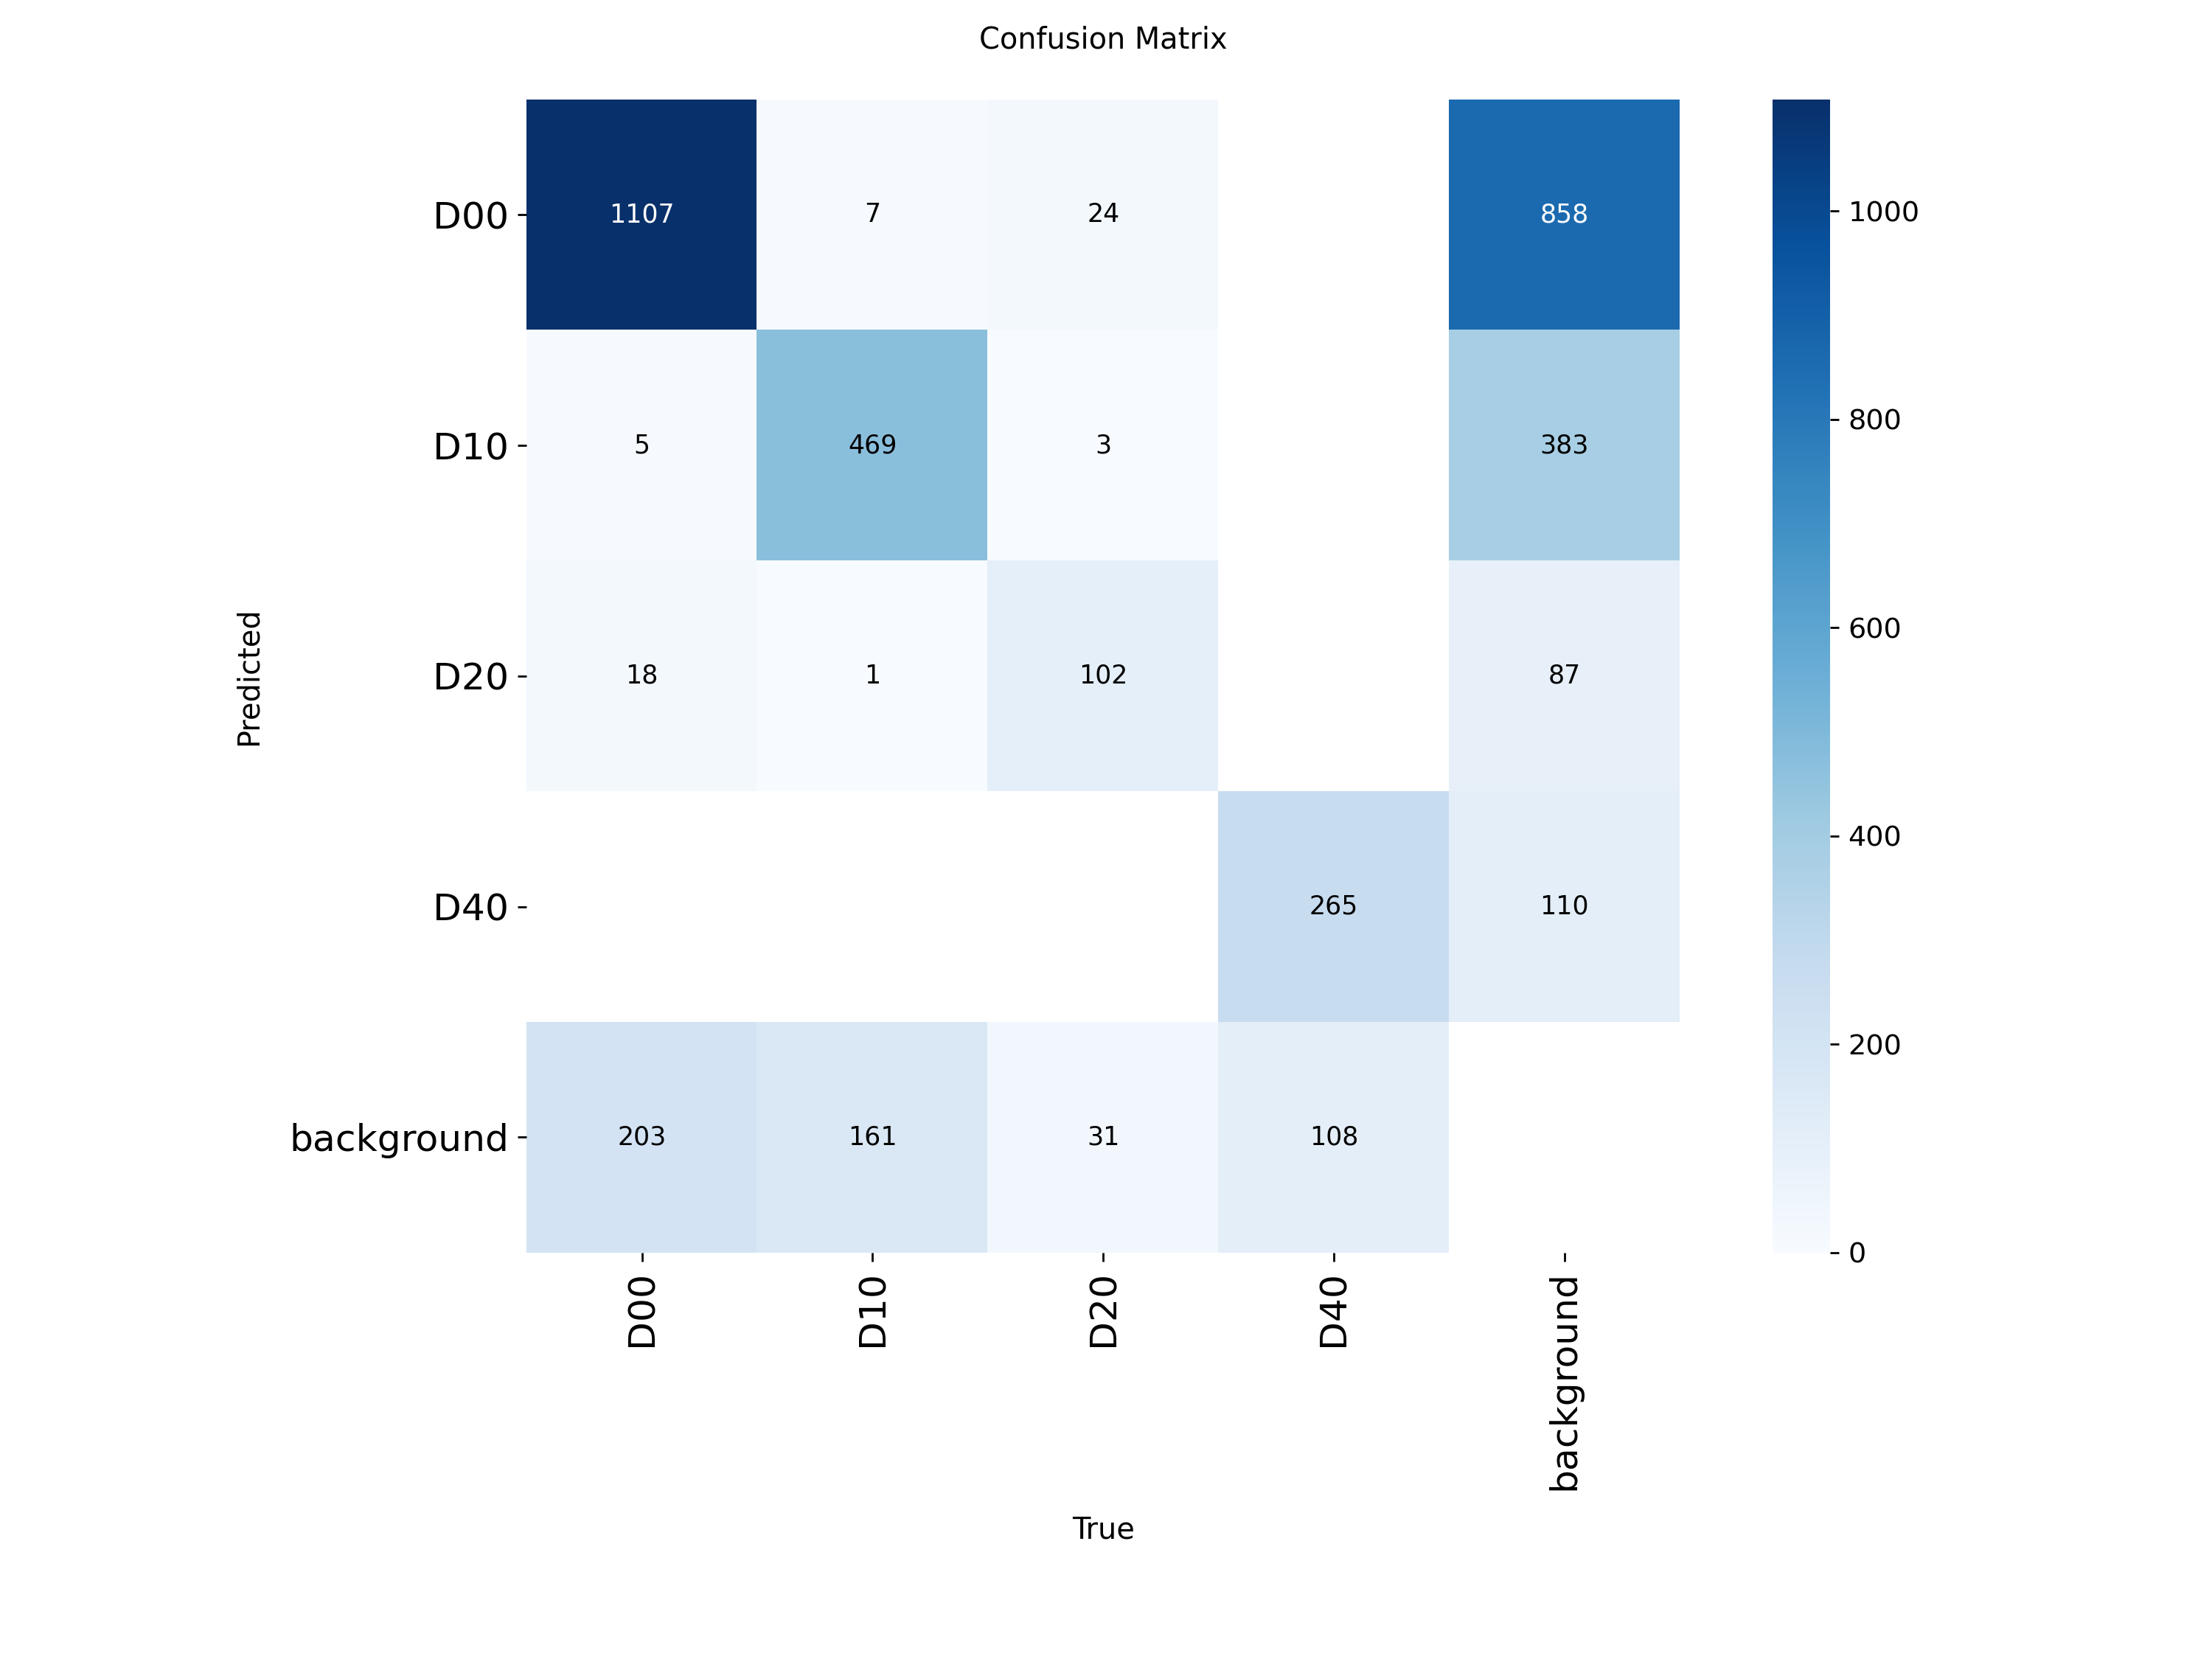

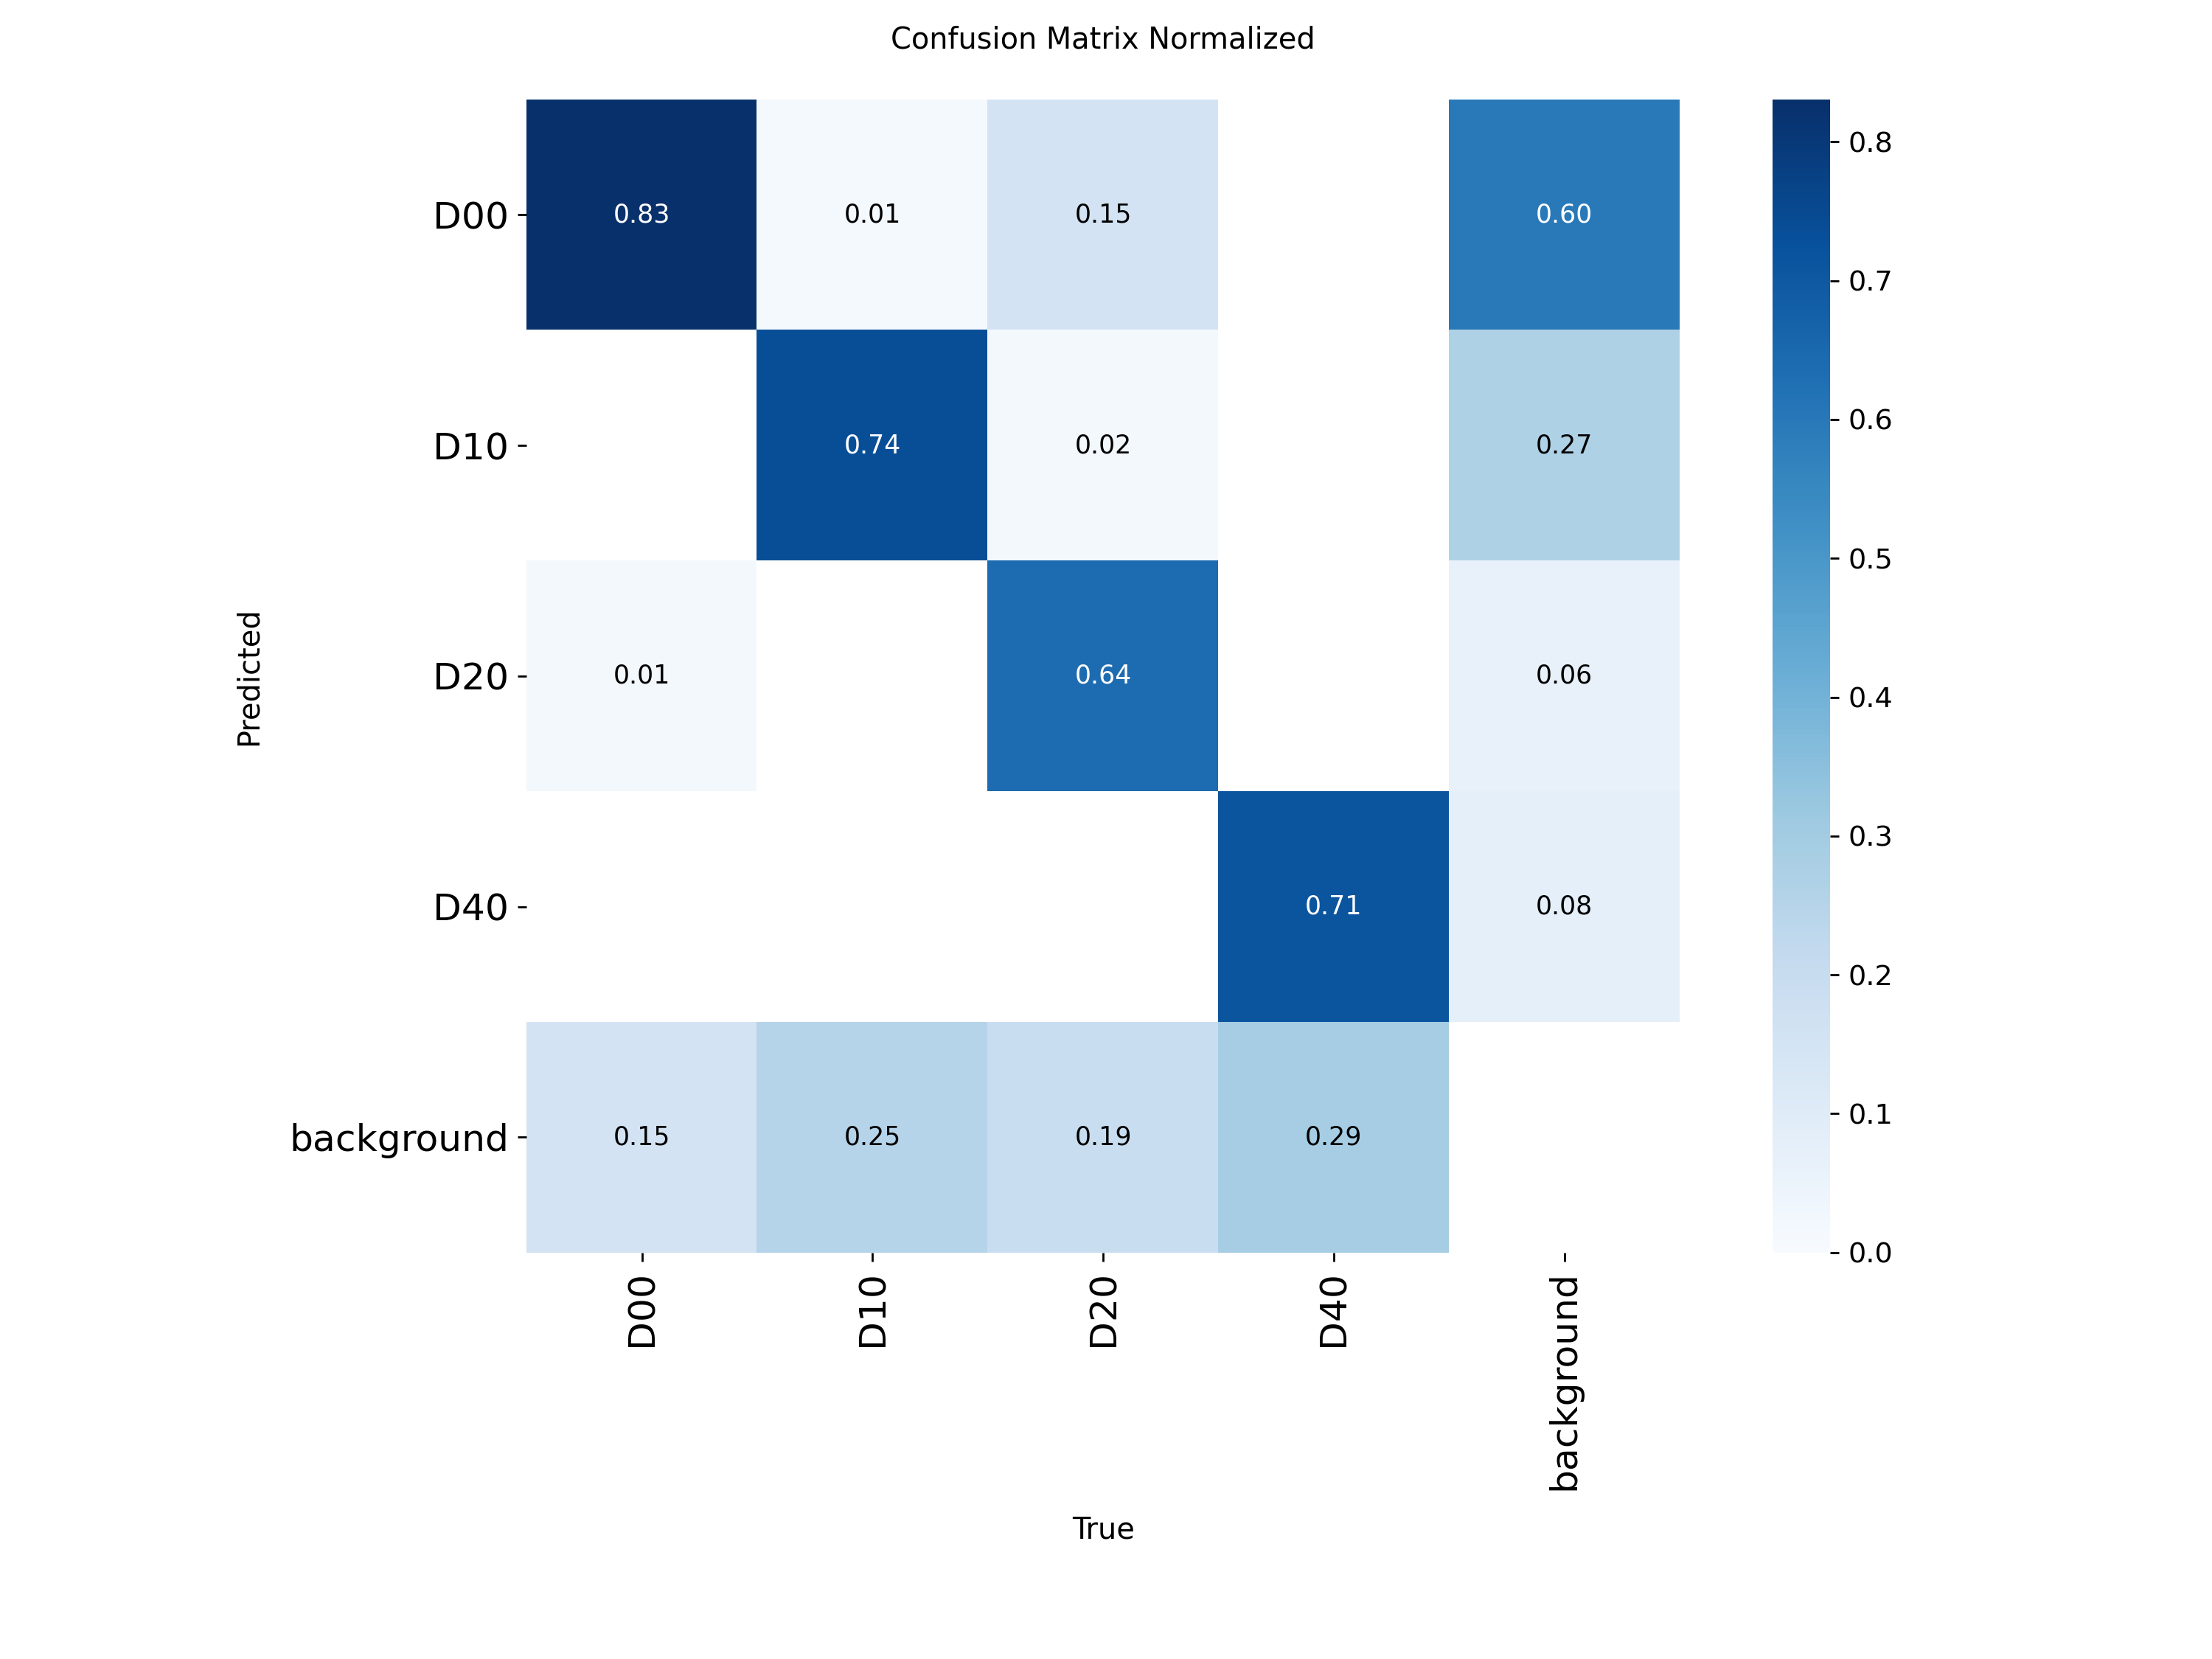

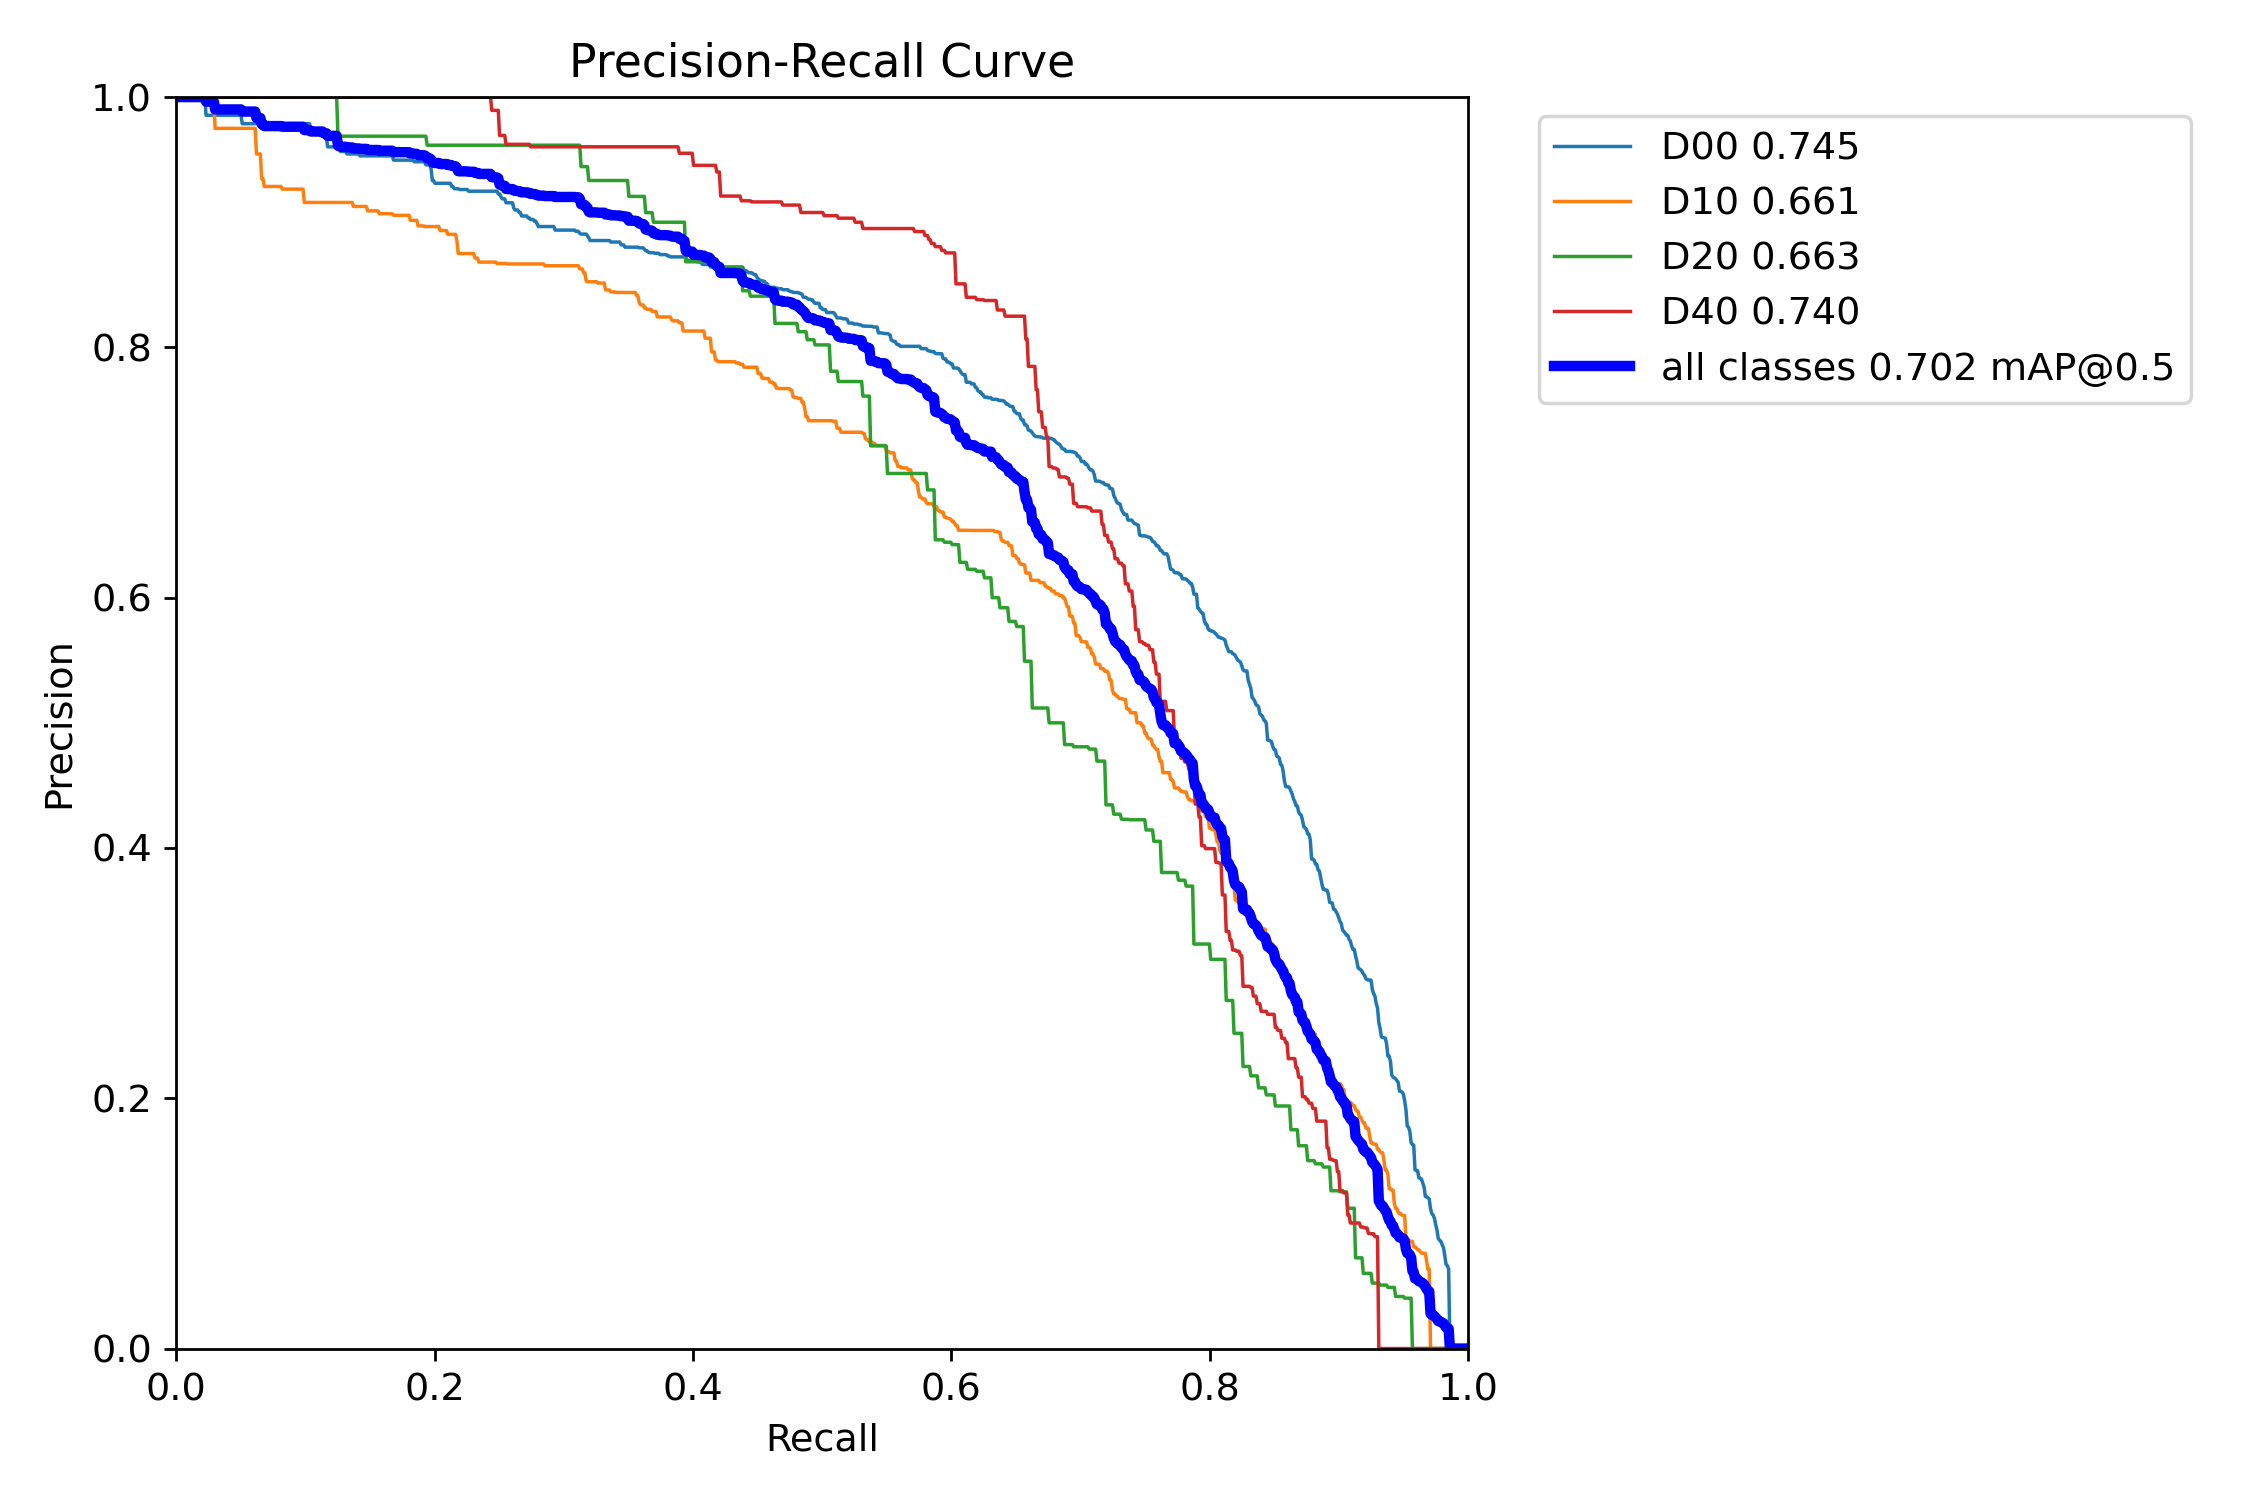

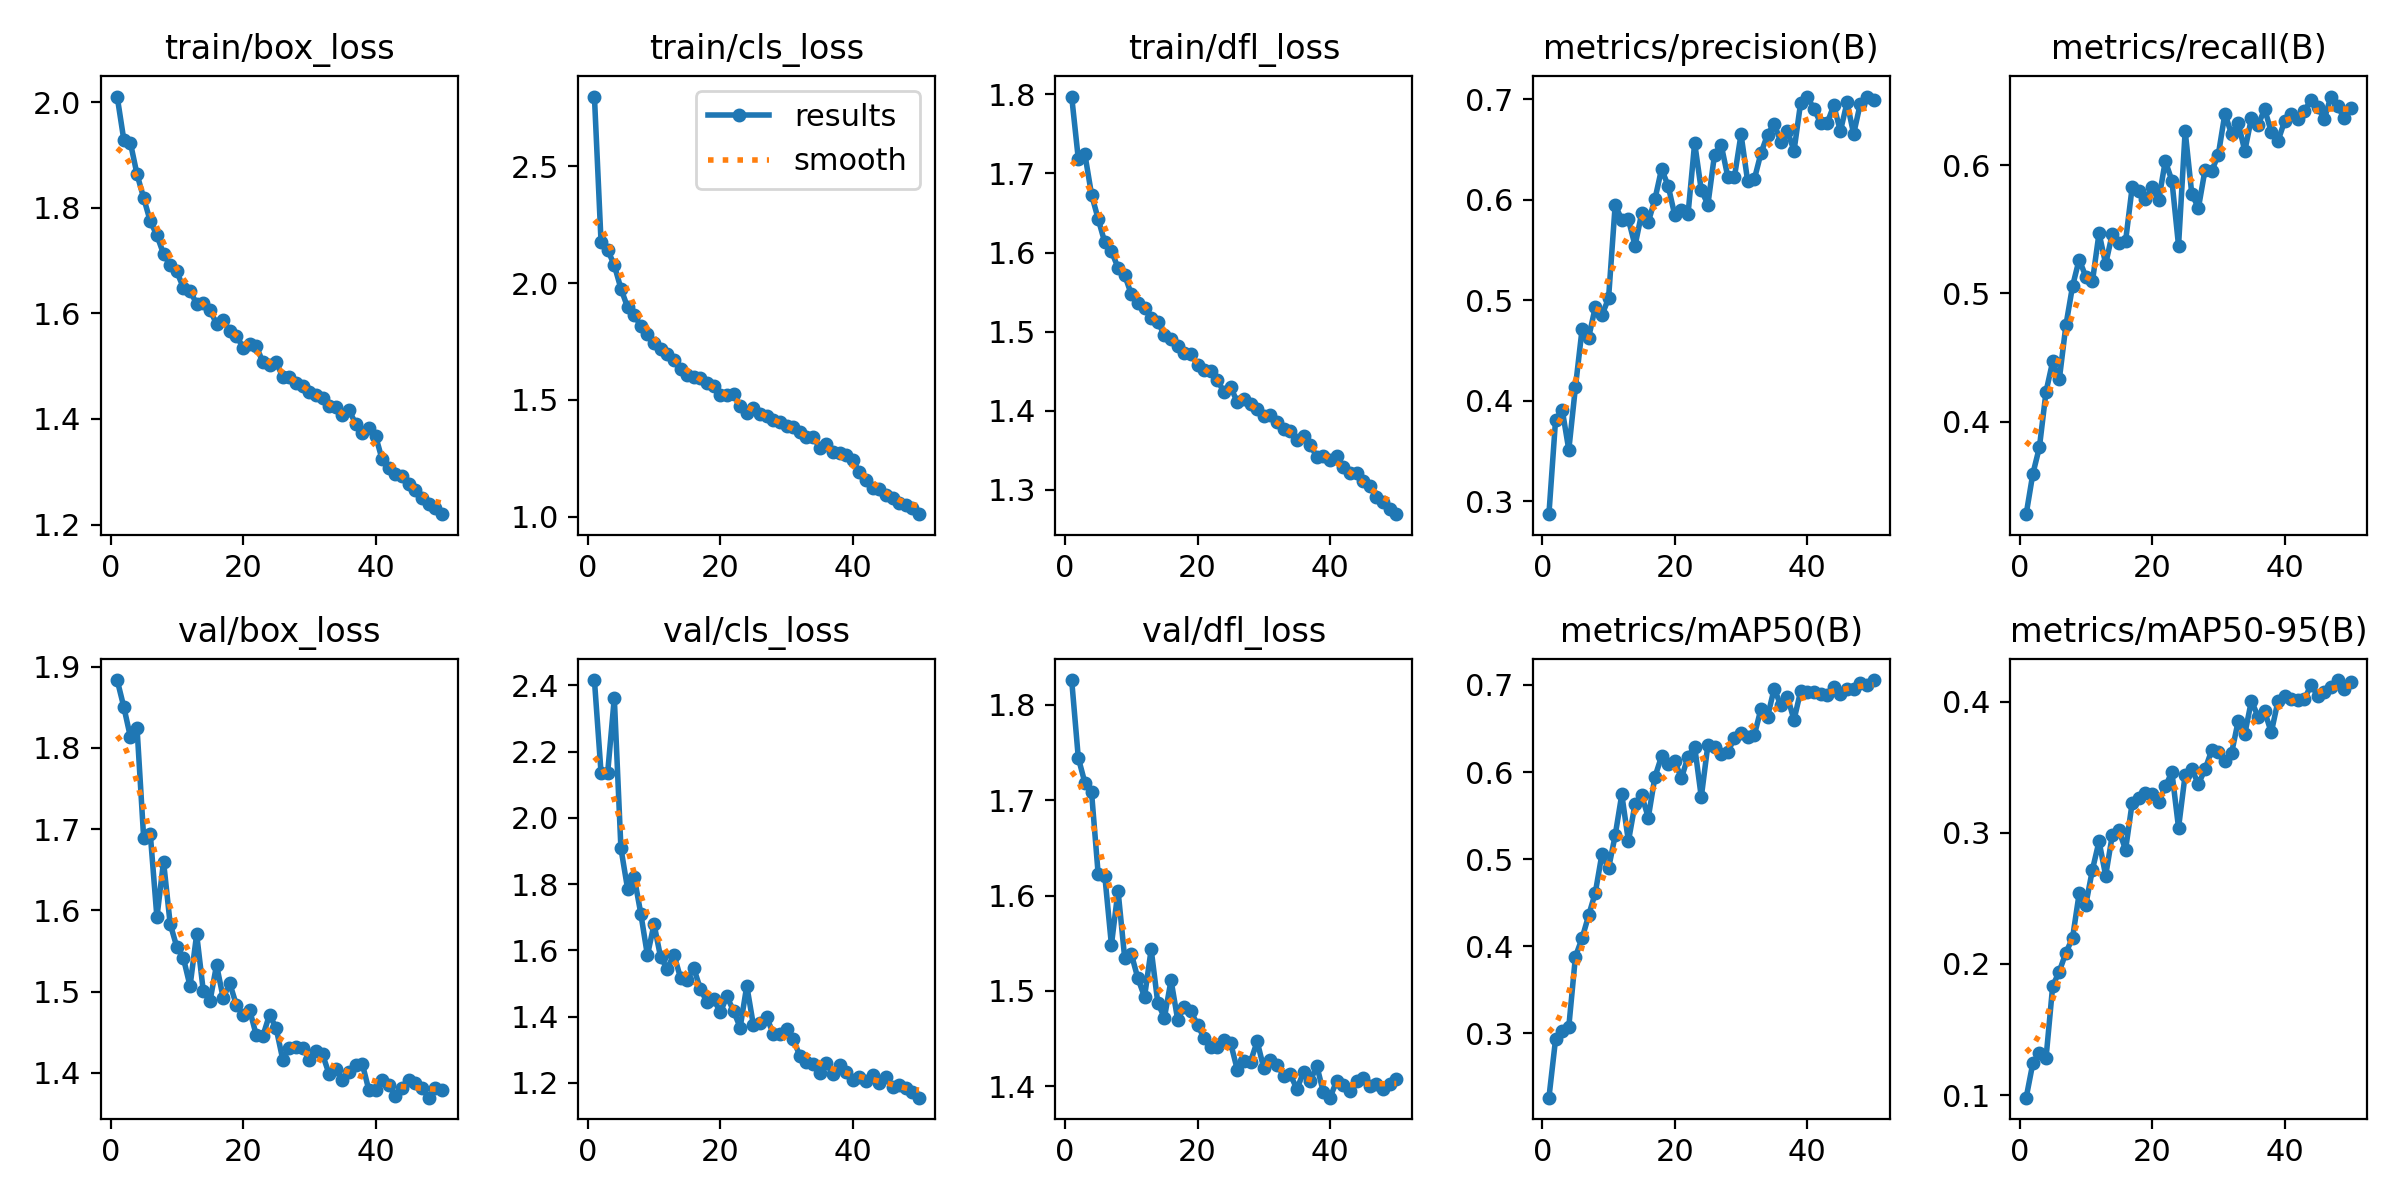

In [25]:
from IPython.display import Image, display

for fig in ["confusion_matrix.png", "confusion_matrix_normalized.png", "BoxPR_curve.png", "results.png"]:
    path = f"{run_dir}/{fig}"
    if os.path.exists(path):
        display(Image(path))

In [21]:
# IPython.display.Image lets us show a saved .png directly in the notebook output.
from IPython.display import Image, display

# Show the key evaluation plots if they exist for this run.
for fig in ["confusion_matrix.png", "PR_curve.png", "results.png"]:
    path = f"{run_dir}/{fig}"
    if os.path.exists(path):
        display(Image(path))


In [22]:
# Re-run validation explicitly to get the numeric metrics back as Python values
# (rather than just reading them off the plots).
metrics = model.val(data="RoadDamageDataset/data.yaml")

print(metrics.box.map)     # mAP50-95 -> stricter average precision across multiple IoU thresholds
print(metrics.box.map50)   # mAP50    -> average precision at a single, looser IoU threshold of 0.5


Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,127,132 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1591.2±614.0 MB/s, size: 76.8 KB)
val: Scanning /content/RoadDamageDataset/labels/val.cache... 1094 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1094/1094 382.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 69/69 4.3it/s 16.1s
                   all       1094       2504      0.696      0.646      0.702      0.417
                   D00        775       1333      0.658      0.744      0.745       0.46
                   D10        468        638      0.667      0.592       0.66      0.339
                   D20        144        160      0.645      0.591      0.663      0.399
                   D40        150        373      0.813      0.657      0.742       0.47
Speed: 1.2ms preprocess, 9.4ms inf

## 8. Test inference on held-out images

Runs the trained model on RDD2022's original unlabeled test images — good for eyeballing real-world performance since these images were never used in training.

In [26]:
# Load the best-performing checkpoint saved during training (not the last epoch,
# the one with the best validation score).
best_weights = f"{run_dir}/weights/best.pt"
model = YOLO(best_weights)

results = model.predict(
    source=f"{master}/images/test",   # folder of images to run predictions on
    imgsz=640,                         # must match (or be close to) the training image size
    conf=0.25,                         # minimum confidence score to keep a detection
    save=True,                         # saves annotated images to a new runs/predict folder
)



WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/1200 /content/RoadDamageDataset/images/test/United_States_004805.jpg: 640x640 2 D10s, 16.1ms
image 2/1200 /content/RoadDamageDataset/images/test/United_States_004806.jpg: 640x640 4 D10s, 1 D20, 16.2ms
image 3/1200 /content/RoadDamageDataset/images/test/United_States_004807.jpg: 640x640 1 D00, 1 D20, 16.1ms
image 4/1200 /content/RoadDamageDataset/images/test/United_States_004808.jpg: 640x640 2 D00s, 16.1ms
image 5/1200 /content/RoadDamageDataset/i

In [27]:
# A second pass focused specifically on potholes, with a lower confidence
# threshold (0.15) so we can see borderline pothole detections too.
results = model.predict(
    source=f"{master}/images/test",
    imgsz=640,
    conf=0.15,
    classes=[3],   # only class index 3 = D40 (pothole); filters out other damage types
    save=True,
)



WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict/ for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

image 1/1200 /content/RoadDamageDataset/images/test/United_States_004805.jpg: 640x640 (no detections), 17.7ms
image 2/1200 /content/RoadDamageDataset/images/test/United_States_004806.jpg: 640x640 (no detections), 16.2ms
image 3/1200 /content/RoadDamageDataset/images/test/United_States_004807.jpg: 640x640 (no detections), 16.2ms
image 4/1200 /content/RoadDamageDataset/images/test/United_States_004808.jpg: 640x640 (no detections), 16.5ms
image 5/1200 /cont

## 9. Download the trained model

This saves `best.pt` to your computer's Downloads folder so you can keep it after the Colab session ends (Colab's storage is wiped when the runtime disconnects).

In [28]:
# Triggers a browser download dialog for the trained weights file.
files.download(best_weights)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 10. (Optional) Streamlit app

A quick demo app so you (or your lecturer) can upload an image/video and see detections without touching code. Update `MODEL_PATH` below if you move the weights file somewhere else.

In [ ]:
# streamlit = the web app framework used to build the demo UI.
# pyngrok   = creates a temporary public URL so you can open the Streamlit app
#             from your browser, since Colab itself can't host a live web server.
!pip install -q streamlit pyngrok


In [ ]:
%%writefile app.py
# %%writefile saves everything below this line into a file called app.py.
# This file is a normal Streamlit script — it does NOT run inside this notebook cell;
# it gets launched separately afterward (see the next cell).
import streamlit as st
from ultralytics import YOLO
import tempfile
import cv2

# Path to the trained weights — update this if you rename/move the run folder.
MODEL_PATH = "RoadDamage_YOLOv8/yolov8s_merged/weights/best.pt"

st.set_page_config(page_title="Road Damage Detection System")
st.title("\U0001F6A7 Road Damage Detection Management System")
st.write("Upload an image or video to detect road damage and potholes.")

# Load the model once when the app starts (not on every upload, to keep it fast).
model = YOLO(MODEL_PATH)

uploaded_file = st.file_uploader("Upload Image or Video", type=["jpg", "png", "mp4"])

if uploaded_file:
    # Streamlit gives us the uploaded file in memory; write it to a temp file on disk
    # so OpenCV/YOLO (which expect a file path) can read it.
    temp_file = tempfile.NamedTemporaryFile(delete=False, suffix="." + uploaded_file.name.split(".")[-1])
    temp_file.write(uploaded_file.read())

    if uploaded_file.type.startswith("image"):
        results = model.predict(temp_file.name, conf=0.25)   # run detection on the image
        st.image(results[0].plot(), channels="BGR")           # display the annotated result
    else:
        st.video(temp_file.name)
        st.info("Video inference: run frame-by-frame prediction in a background step for full results.")
